In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
print("hello")

hello


In [6]:

data = {
    'weight': [50, 55, 58, 60, 62, 65, 68, 70, 72, 75,
               78, 80, 82, 85, 88, 90, 92, 95, 98, 100],
    'height': [150, 153, 155, 157, 158, 160, 162, 163, 165, 167,
               169, 170, 171, 173, 175, 176, 178, 180, 182, 183]
}

df = pd.DataFrame(data)
df.head()

,weight,height
0,50,150
1,55,153
2,58,155
3,60,157
4,62,158


Text(0.5, 0, 'Weight')

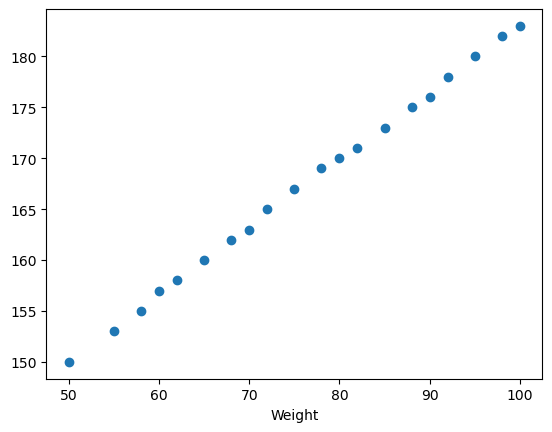

In [7]:
plt.scatter(df['weight'],df['height'])
plt.xlabel("Weight")


In [8]:
df.corr()

,weight,height
weight,1.000000,0.999613
height,0.999613,1.000000


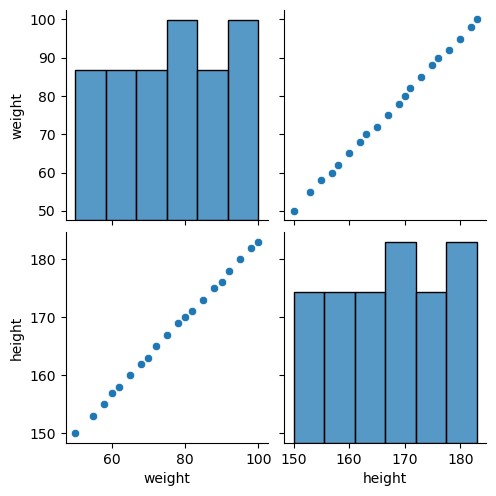

In [9]:
import seaborn as sns
sns.pairplot(df)

In [10]:
x=df[['weight']]
y=df['height']

In [11]:
y

0     150
1     153
2     155
3     157
4     158
5     160
6     162
7     163
8     165
9     167
10    169
11    170
12    171
13    173
14    175
15    176
16    178
17    180
18    182
19    183
Name: height, dtype: int64

In [12]:
x

,weight
0,50
1,55
2,58
3,60
4,62
5,65
6,68
7,70
8,72
9,75


In [13]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.25, random_state=42)

In [14]:
xtrain.shape

(15, 1)

In [15]:
ytest.shape

(5,)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [17]:
xtest

array([[-2.09508534],
       [ 1.34574825],
       [ 0.96343341],
       [-1.7127705 ],
       [-0.41290003]])

In [18]:
from sklearn.linear_model import LinearRegression

lr= LinearRegression()


In [20]:
lr.fit(xtrain,ytrain)

LinearRegression()

In [21]:
lr

LinearRegression()

In [22]:
lr.coef_

array([8.65458856])

In [23]:
lr.intercept_

168.2

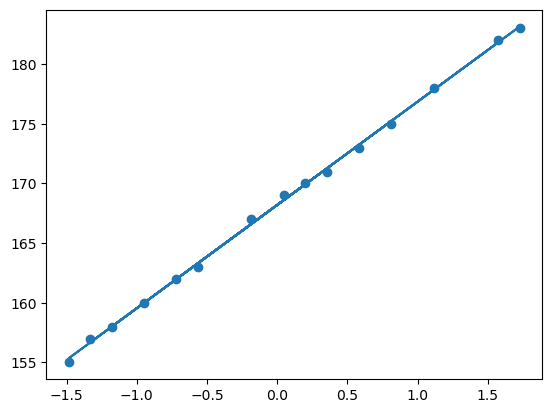

In [26]:
# plot training data
plt.scatter(xtrain,ytrain)
plt.plot(xtrain,lr.predict(xtrain))

In [28]:
y_pred = lr.predict(xtest)

In [31]:
# performance

from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest,y_pred)
rmse = np.sqrt(mse)

In [32]:
print(mse, mae, rmse)

0.11979909841165189 0.30185531649516406 0.3461200635785968


In [33]:
from sklearn.metrics import r2_score
score = r2_score(ytest,y_pred)
score

0.9991620096641602

In [34]:
import statsmodels.api as sm

model = sm.OLS(ytrain,xtrain).fit()

In [35]:
prediction = model.predict(xtest)
prediction

array([-18.13210165,  11.64689741,   8.33811974, -14.82332398,
        -3.57347989])

In [38]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 height   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):             -0.069
Method:                 Least Squares   F-statistic:                            0.03707
Date:                Wed, 06 May 2026   Prob (F-statistic):                       0.850
Time:                        23:26:13   Log-Likelihood:                         -98.161
No. Observations:                  15   AIC:                                      198.3
Df Residuals:                      14   BIC:                                      199.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\admin\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samples, **kwds)


In [41]:
# prediction for new data
lr.predict(scaler.transform([[72]]))

c:\Users\admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([164.62652011])